In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd 
import pandas as pd

In [2]:
project_root = Path.cwd()
if not Path('data').exists():
    project_root = project_root.parent
print(project_root)

d:\Wu\2026\Project Portfolio\003 Project\grocery-demand-estimation


### Load spatial data

In [3]:
demand_path = project_root / 'data/processed/potential_grocery_demand.gpkg'
city_path = project_root / 'data/processed/kootenai_cities.gpkg'

In [4]:
demand = gpd.read_file(demand_path, layer='tract_demand')
city = gpd.read_file(city_path, layer='cities')

In [5]:
demand.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'state', 'county', 'tract', 'household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery', 'potential_grocery_deman',
       'geometry'],
      dtype='str')

In [6]:
demo_list = ['household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery']


### Grocery expenditure analysis at Household level 

In [7]:
demand['avg_grocery'].value_counts()

avg_grocery
5842.281205    25
7120.717148    11
4926.023063     3
Name: count, dtype: int64

In [8]:
demand['avg_grocery'].unique()

array([7120.71714758, 4926.02306334, 5842.28120479])

In [9]:
for v in demand['avg_grocery'].unique():
    print(repr(v))

np.float64(7120.717147583165)
np.float64(4926.023063341427)
np.float64(5842.281204792462)


#### Create Grocery labels

In [10]:
grocery_labels = {
    4926.02: "Low",
    5842.28: "Medium",
    7120.72: "High"
}

demand["grocery_group"] = demand["avg_grocery"].round(2).map(grocery_labels)
demand[["avg_grocery", "grocery_group"]].head()

,avg_grocery,grocery_group
0,7120.717148,High
1,4926.023063,Low
2,5842.281205,Medium
3,5842.281205,Medium
4,5842.281205,Medium


#### Summarize demographics

In [11]:
grocery_summary = (
    demand
    .groupby("grocery_group")[
        [
            "household_count",
            "avg_household_size",
            "median_income",
            "median_age",
            "owner_rate",
            "college_plus_pct"
        ]
    ]
    .mean()
    .round(2)
)

grocery_summary

,household_count,avg_household_size,median_income,median_age,owner_rate,college_plus_pct
grocery_group,,,,,,
High,1724.09,2.58,106513.73,47.48,84.80,35.83
Low,1621.67,1.81,40838.33,44.33,31.14,21.55
Medium,1893.68,2.54,79257.36,42.63,72.21,29.45


#### Correlation 

In [12]:
corr_df = demand[demo_list]

In [13]:
corr_matrix = corr_df.corr()

grocery_corr = (
    corr_matrix["avg_grocery"]
    .drop("avg_grocery")
    .sort_values(ascending=False)
)

grocery_corr.round(2)

median_income         0.83
owner_rate            0.64
college_plus_pct      0.41
avg_household_size    0.35
median_age            0.23
household_count      -0.04
Name: avg_grocery, dtype: float64

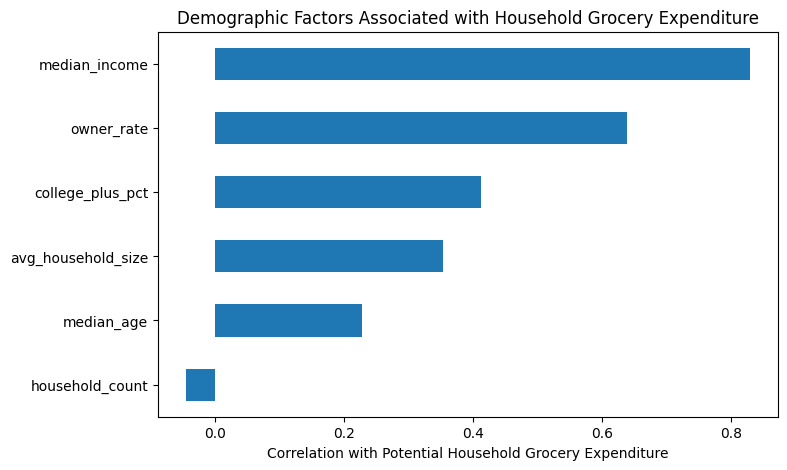

In [14]:
grocery_corr.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel("Correlation with Potential Household Grocery Expenditure")
plt.title("Demographic Factors Associated with Household Grocery Expenditure")
plt.show()